# Load Heart Disease Dataset

In [2]:
import pandas as pd
df = pd.read_csv('../data/heart_disease.csv')
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


# Check Missing Values

In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing values: 6


# Handle Missing Values with Imputation

In [4]:
from sklearn.impute import SimpleImputer
import numpy as np

df_imputed = df.copy()
numeric_columns = df_imputed.select_dtypes(include=[np.number]).columns
imputer = SimpleImputer(strategy='median')
df_imputed[numeric_columns] = imputer.fit_transform(df_imputed[numeric_columns])
print("Missing values after imputation:", df_imputed.isnull().sum().sum())

Missing values after imputation: 0


# Identify Categorical Variables

In [7]:
categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
print("Categorical columns:", categorical_columns)
print("Data types:")
print(df_imputed.dtypes)

Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target      float64
dtype: object


# Determine Categorical vs Numerical Variables

In [ ]:
categorical_columns = []
numerical_columns = []

for col in df_imputed.columns:
    if col in ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']:
        numerical_columns.append(col)
    elif col in ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']:
        categorical_columns.append(col)
    elif col in ['ca', 'thal']:
        if df_imputed[col].nunique() <= 4:
            categorical_columns.append(col)
        else:
            numerical_columns.append(col)
    elif col == 'target':
        continue

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)

Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


# Perform One-Hot Encoding

In [9]:
df_encoded = pd.get_dummies(df_imputed, columns=categorical_columns, drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")
print("New columns created:")
print(df_encoded.columns.tolist())

Shape after encoding: (303, 21)
New columns created:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target', 'sex_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_1.0', 'restecg_1.0', 'restecg_2.0', 'exang_1.0', 'slope_2.0', 'slope_3.0', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_6.0', 'thal_7.0']


# Separate Features and Target

In [11]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (303, 20)
Target shape: (303,)


# Standardize Numerical Features

In [12]:
from sklearn.preprocessing import StandardScaler

X_scaled = X.copy()
scaler = StandardScaler()
X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])
print("Standardization completed")
print("Mean of scaled features:", X_scaled[numerical_features].mean().round(2))
print("Std of scaled features:", X_scaled[numerical_features].std().round(2))

Standardization completed
Mean of scaled features: age        -0.0
trestbps    0.0
chol        0.0
thalach    -0.0
oldpeak     0.0
dtype: float64
Std of scaled features: age         1.0
trestbps    1.0
chol        1.0
thalach     1.0
oldpeak     1.0
dtype: float64


# EDA: Distribution Histograms

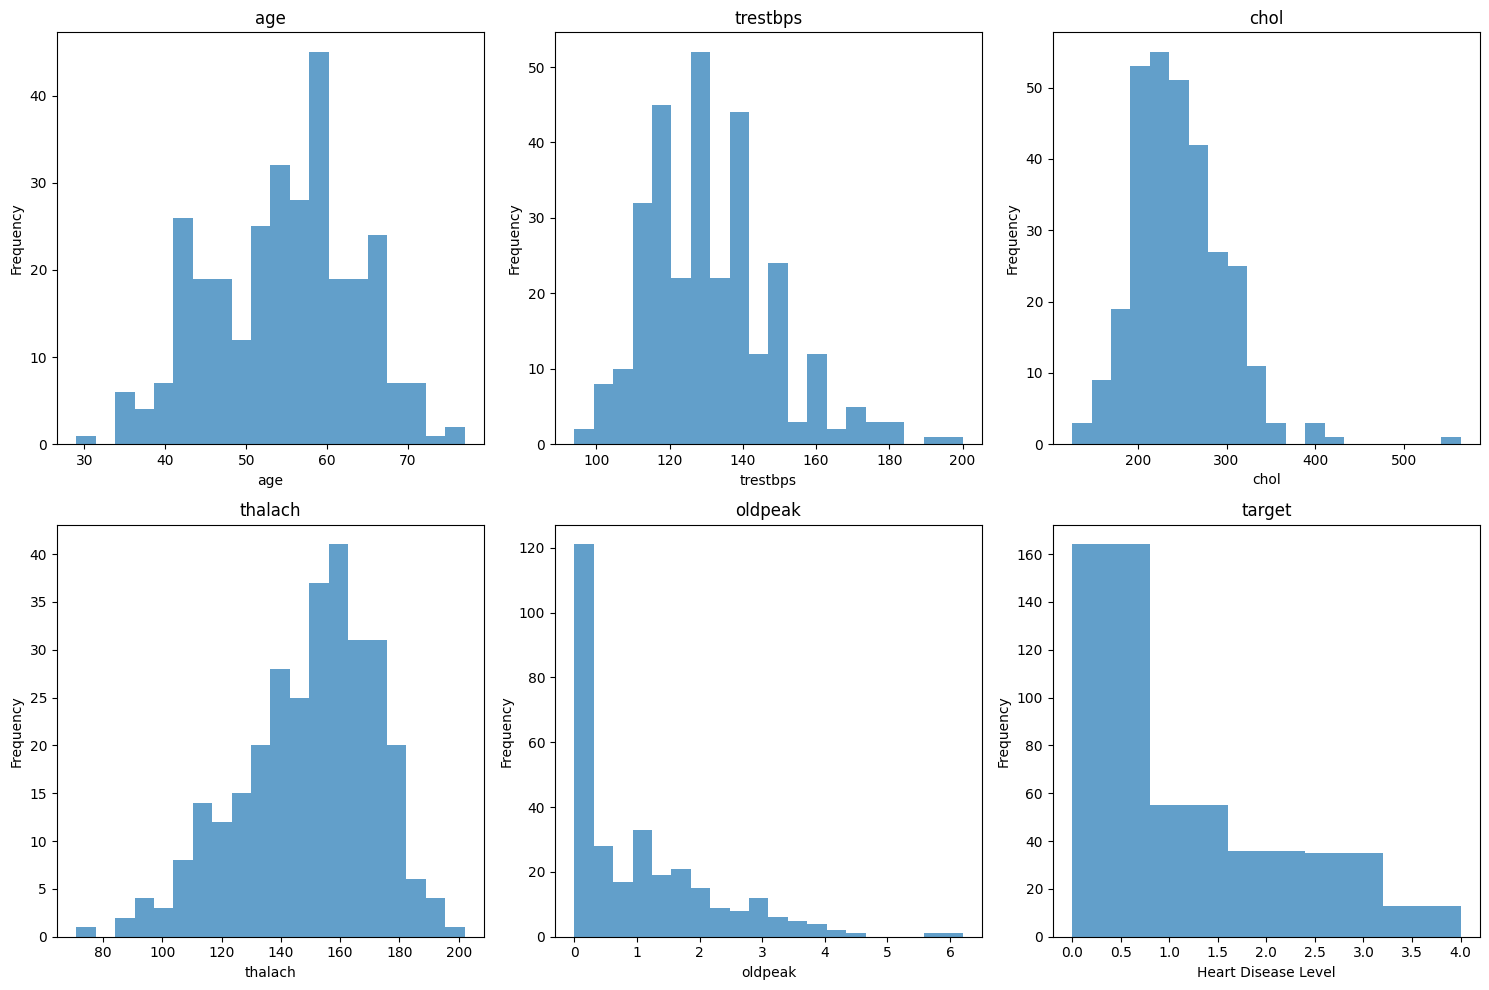

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_features):
    axes[i].hist(df_imputed[col], bins=20, alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[5].hist(y, bins=5, alpha=0.7)
axes[5].set_title('target')
axes[5].set_xlabel('Heart Disease Level')
axes[5].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# EDA: Correlation Heatmap

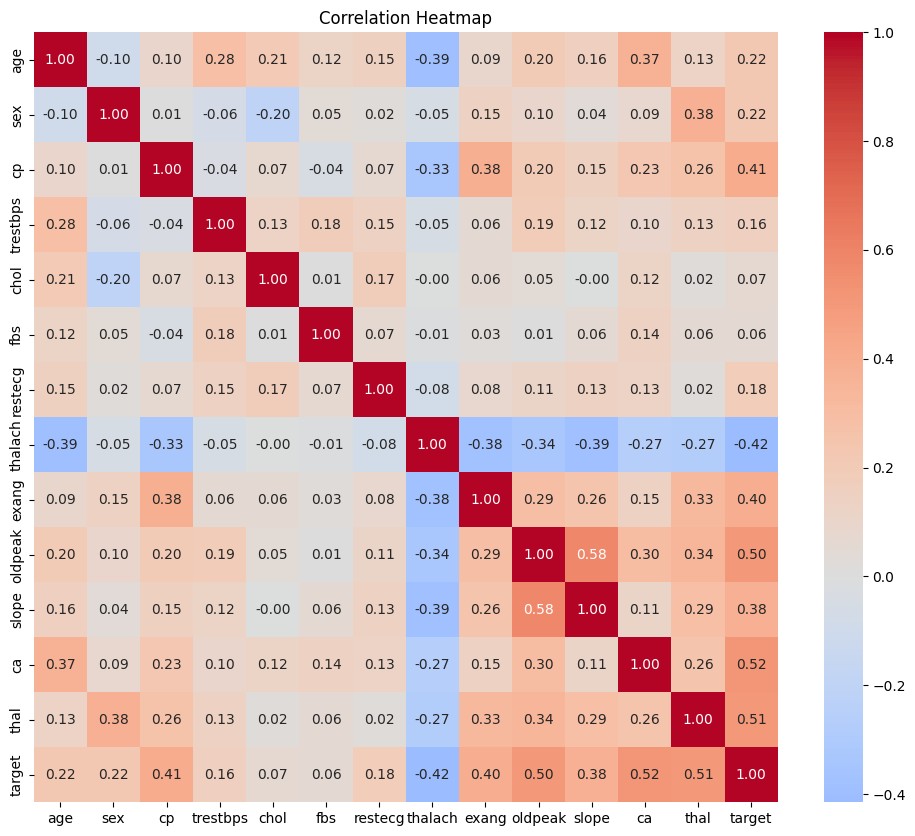

In [14]:
import seaborn as sns

plt.figure(figsize=(12, 10))
correlation_matrix = df_imputed.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# EDA: Boxplots for Numerical Features

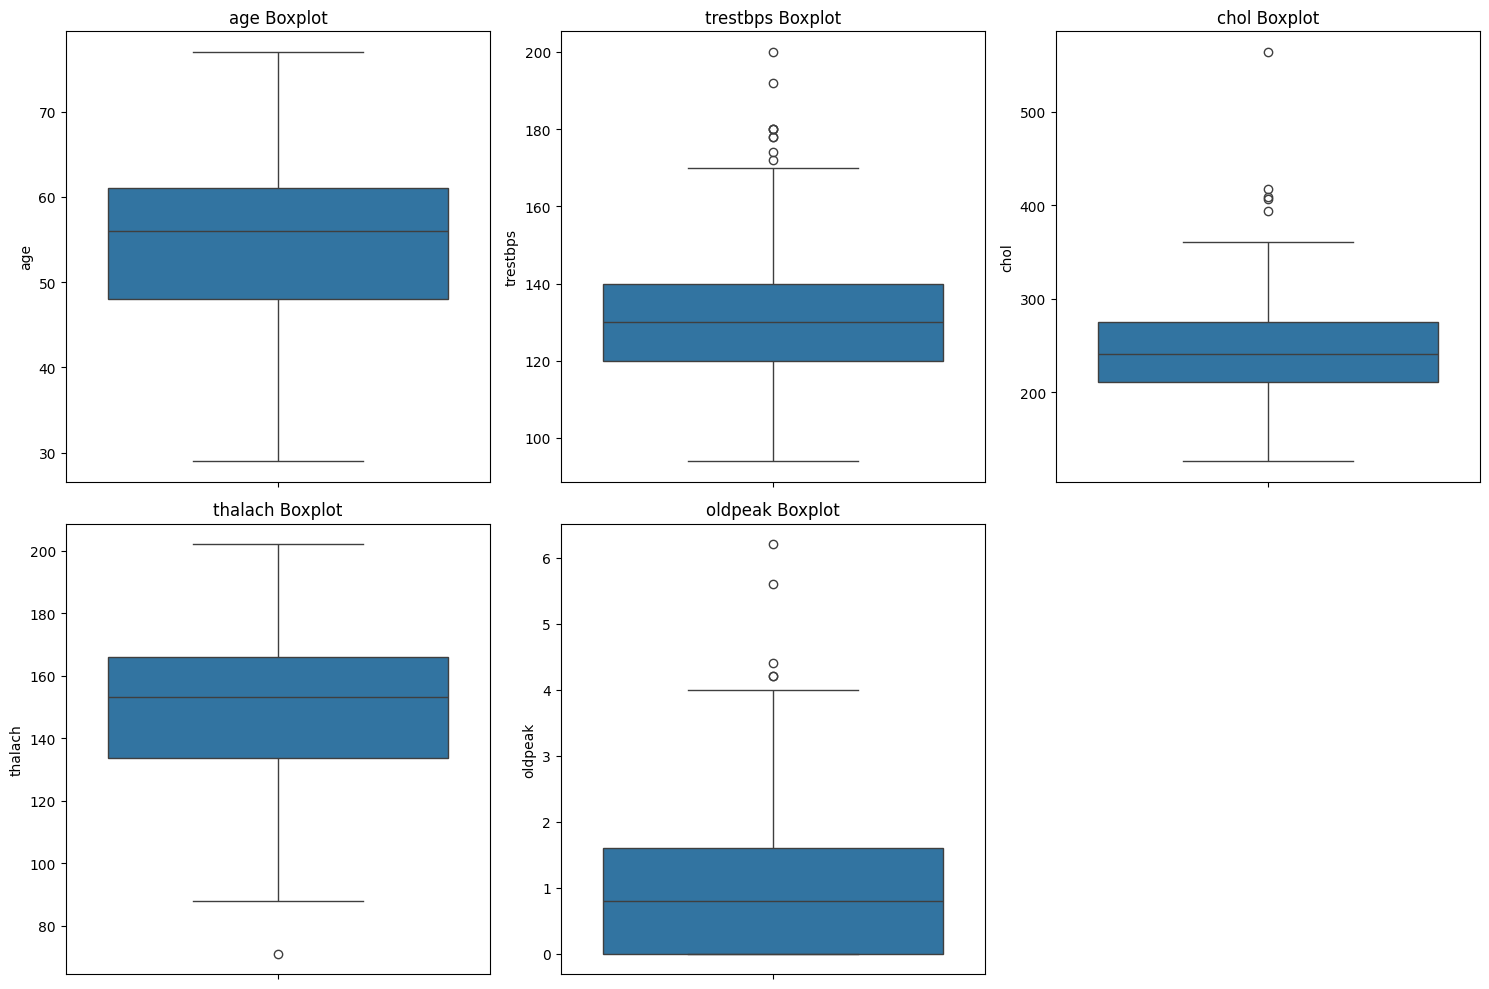

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_features):
    sns.boxplot(data=df_imputed, y=col, ax=axes[i])
    axes[i].set_title(f'{col} Boxplot')

axes[5].axis('off')
plt.tight_layout()
plt.show()